In [11]:
%pip -q install xgboost optuna scikit-learn scipy pandas numpy


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from scipy.stats import skew, kurtosis
from scipy.fft import rfft, rfftfreq
from scipy.signal import welch
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

USE_OPTUNA = False
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    USE_OPTUNA = True
    print('Optuna available — hyperparameter tuning enabled')
except ImportError:
    print('Optuna not installed — using default XGBoost params')

SEED = 42
np.random.seed(SEED)
print('All imports OK')

Optuna available — hyperparameter tuning enabled
All imports OK


In [13]:
DATA_DIR = Path('.')

TRAIN_DATA  = pd.read_csv(DATA_DIR / 'train-sensor.csv')
TRAIN_LABEL = pd.read_csv(DATA_DIR / 'train-label.csv')
TEST_DATA   = pd.read_csv(DATA_DIR / 'test-sensor.csv')

# ---- clean types (from v24) ----
SENSOR_COLS_V24 = ['accel_x', 'accel_y', 'accel_z', 'eda', 'heart_rate', 'temperature']

def clean_sensor(d):
    out = d.copy()
    out['pid'] = out['pid'].astype(str)
    out['timestamp'] = pd.to_numeric(out['timestamp'], errors='coerce').astype(float)
    for c in SENSOR_COLS_V24:
        out[c] = pd.to_numeric(out[c], errors='coerce').astype(float)
    out['accel_x'] = out['accel_x'].clip(-128, 127)
    out['accel_y'] = out['accel_y'].clip(-128, 127)
    out['accel_z'] = out['accel_z'].clip(-128, 127)
    out['eda']          = out['eda'].clip(0, 60)
    out['heart_rate']   = out['heart_rate'].clip(40, 190)
    out['temperature']  = out['temperature'].clip(20, 40)
    return out.sort_values(['pid', 'timestamp']).reset_index(drop=True)

def clean_label(d):
    out = d.copy()
    out['pid']       = out['pid'].astype(str)
    out['timestamp'] = pd.to_numeric(out['timestamp'], errors='coerce').astype(float)
    out['stress']    = pd.to_numeric(out['stress'], errors='coerce')
    return out

TRAIN_DATA  = clean_sensor(TRAIN_DATA)
TRAIN_LABEL = clean_label(TRAIN_LABEL)
TEST_DATA   = clean_sensor(TEST_DATA)

print('Cleaned.')
print('  TRAIN_DATA :', TRAIN_DATA.shape)
print('  TRAIN_LABEL:', TRAIN_LABEL.shape)
print('  TEST_DATA  :', TEST_DATA.shape)

# ---- merge sensor + label on pid + nearest timestamp ----
TRAIN_DATA = pd.merge_asof(
    TRAIN_DATA.sort_values('timestamp'),
    TRAIN_LABEL[['pid', 'timestamp', 'stress']].sort_values('timestamp'),
    on='timestamp', by='pid', direction='nearest'
)
TRAIN_DATA = TRAIN_DATA.dropna(subset=['stress']).reset_index(drop=True)

# ---- rename to improved-notebook column names ----
COL_MAP = {
    'accel_x':    'X',
    'accel_y':    'Y',
    'accel_z':    'Z',
    'eda':        'EDA',
    'heart_rate': 'HR',
    'temperature':'TEMP',
    'pid':        'id',
    'timestamp':  'datetime',
    'stress':     'label',
}
df = TRAIN_DATA.rename(columns=COL_MAP)
df['datetime'] = pd.to_datetime(df['datetime'], unit='ms', errors='coerce')
df['label']    = df['label'].astype(int)

print(f'\nFinal df: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Nurses (id): {sorted(df["id"].unique())}')
print('\nLabel distribution:')
print(df['label'].value_counts().sort_index())

Cleaned.
  TRAIN_DATA : (4694400, 8)
  TRAIN_LABEL: (815, 4)
  TEST_DATA  : (5921280, 8)

Final df: 4,694,400 rows × 9 cols
Nurses (id): ['43JW', 'C8Q6', 'DT5C', 'F1ZM', 'HDS9', 'P4DZ', 'TPQI']

Label distribution:
label
0     933120
1     380160
2    3381120
Name: count, dtype: int64


In [14]:
# Section 2 — Data Cleaning & Segment Detection
FS = 32          # Hz
WINDOW_SEC = 10  # seconds
WINDOW_SIZE = FS * WINDOW_SEC   # 320 samples
WARMUP_SEC = 600                 # 10-minute warm-up to drop
MIN_SEG_SEC = 60                 # ignore segments shorter than this
GAP_THRESH = 0.1                 # seconds — time gap that marks a new segment

def assign_segments(nurse_df):
    nurse_df = nurse_df.sort_values('datetime').copy()
    time_diff = nurse_df['datetime'].diff().dt.total_seconds().fillna(0)
    nurse_df['segment'] = (time_diff > GAP_THRESH).cumsum()

    valid_rows = []
    for seg_id, seg in nurse_df.groupby('segment'):
        if len(seg) < MIN_SEG_SEC * FS:
            continue
        seg = seg.iloc[WARMUP_SEC * FS:]
        if len(seg) >= WINDOW_SIZE:
            valid_rows.append(seg)

    if not valid_rows:
        return pd.DataFrame()
    return pd.concat(valid_rows).reset_index(drop=True)

print('Cleaning segments per nurse...')
cleaned_parts = []
for nurse_id, grp in df.groupby('id'):
    cleaned = assign_segments(grp)
    if not cleaned.empty:
        cleaned_parts.append(cleaned)

df_clean = pd.concat(cleaned_parts, ignore_index=True)
print(f'After cleaning: {df_clean.shape[0]:,} rows')
del df; gc.collect()

Cleaning segments per nurse...
After cleaning: 3,421,440 rows


1190

In [15]:
SIGNAL_COLS = ['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP']

def per_nurse_normalize(df):
    df = df.copy()
    for nurse_id, idx in df.groupby('id').groups.items():
        subset = df.loc[idx, SIGNAL_COLS]
        mu = subset.mean()
        sigma = subset.std().replace(0, 1)  # avoid div-by-zero
        df.loc[idx, SIGNAL_COLS] = (subset - mu) / sigma
    return df

print('Applying per-nurse Z-score normalization...')
df_norm = per_nurse_normalize(df_clean)
print('Done.')

# Gaussian smoothing on HR and EDA to remove staircase artifact
print('Applying Gaussian smoothing to HR and EDA...')
for nurse_id, idx in df_norm.groupby('id').groups.items():
    df_norm.loc[idx, 'HR']  = gaussian_filter1d(df_norm.loc[idx, 'HR'].values,  sigma=4)
    df_norm.loc[idx, 'EDA'] = gaussian_filter1d(df_norm.loc[idx, 'EDA'].values, sigma=4)
print('Done.')

Applying per-nurse Z-score normalization...
Done.
Applying Gaussian smoothing to HR and EDA...
Done.


In [16]:
# --- Helper functions ---

def rmssd(signal):
    """Root Mean Square of Successive Differences — HRV proxy."""
    diffs = np.diff(signal)
    return np.sqrt(np.mean(diffs ** 2)) if len(diffs) > 0 else 0.0

def eda_spike_count(eda, threshold=0.02):
    """Count EDA peaks above threshold * std."""
    thresh = threshold * np.std(eda)
    diffs = np.diff(eda)
    return int(np.sum((diffs[:-1] < thresh) & (diffs[1:] > thresh)))

def linear_slope(signal):
    """Slope of linear fit — captures trend direction."""
    x = np.arange(len(signal))
    return np.polyfit(x, signal, 1)[0]

def welch_band_power(signal, fs, low, high):
    """Power in a frequency band using Welch's method."""
    f, psd = welch(signal, fs=fs, nperseg=min(len(signal), 64))
    idx = (f >= low) & (f < high)
    return np.trapezoid(psd[idx], f[idx]) if idx.any() else 0.0

def xcorr_lag(sig1, sig2):
    """Lag (in samples) of maximum cross-correlation between two signals."""
    corr = np.correlate(sig1 - sig1.mean(), sig2 - sig2.mean(), mode='full')
    return int(np.argmax(corr) - (len(sig1) - 1))

def extract_features(window):
    """Extract all features from a single 320-sample window DataFrame."""
    feats = {}

    X_  = window['X'].values
    Y_  = window['Y'].values
    Z_  = window['Z'].values
    EDA = window['EDA'].values
    HR  = window['HR'].values
    TMP = window['TEMP'].values

    # Derived signals
    acc_mag  = np.sqrt(X_**2 + Y_**2 + Z_**2)
    acc_jerk = np.sqrt(np.diff(X_)**2 + np.diff(Y_)**2 + np.diff(Z_)**2)
    eda_diff = np.diff(EDA)
    hr_diff  = np.diff(HR)

    stress_index = np.mean(EDA) * np.std(HR)          # physiological combo
    move_stress  = np.mean(acc_mag) / (np.mean(np.abs(EDA)) + 1e-6)
    eda_auc = np.trapezoid(np.abs(EDA))               # area under EDA curve

    # --- Per-signal statistics ---
    for name, sig in [('EDA', EDA), ('HR', HR), ('TEMP', TMP),
                       ('acc_mag', acc_mag), ('acc_jerk', acc_jerk),
                       ('eda_diff', eda_diff), ('hr_diff', hr_diff)]:
        feats[f'{name}_mean']  = np.mean(sig)
        feats[f'{name}_std']   = np.std(sig)
        feats[f'{name}_min']   = np.min(sig)
        feats[f'{name}_max']   = np.max(sig)
        feats[f'{name}_skew']  = float(skew(sig))
        feats[f'{name}_kurt']  = float(kurtosis(sig))

    # --- Physiological features ---
    feats['RMSSD']            = rmssd(HR)
    feats['eda_spikes']       = eda_spike_count(EDA)
    feats['stress_index']     = stress_index
    feats['move_stress_ratio']= move_stress
    feats['eda_auc']          = eda_auc

    # --- Slopes ---
    feats['HR_slope']         = linear_slope(HR)
    feats['EDA_slope']        = linear_slope(EDA)
    feats['TEMP_slope']       = linear_slope(TMP)

    # --- Spectral (Welch PSD bands) ---
    # EDA: very low frequency (0–0.1 Hz) and low (0.1–0.5 Hz)
    feats['EDA_psd_vlf']      = welch_band_power(EDA, FS, 0.0, 0.1)
    feats['EDA_psd_lf']       = welch_band_power(EDA, FS, 0.1, 0.5)
    # HR: LF (0.04–0.15 Hz), HF (0.15–0.4 Hz)
    feats['HR_psd_lf']        = welch_band_power(HR,  FS, 0.04, 0.15)
    feats['HR_psd_hf']        = welch_band_power(HR,  FS, 0.15, 0.40)
    feats['HR_lf_hf_ratio']   = feats['HR_psd_lf'] / (feats['HR_psd_hf'] + 1e-9)

    # --- HR-EDA cross-correlation lag ---
    feats['hr_eda_xcorr_lag'] = xcorr_lag(HR, EDA)

    return feats


def build_feature_matrix(df):
    """Slide a 10-second window over each nurse's cleaned data and extract features."""
    all_feats, all_labels, all_groups = [], [], []

    for nurse_id, nurse_df in df.groupby('id'):
        nurse_df = nurse_df.reset_index(drop=True)
        n = len(nurse_df)
        num_windows = n // WINDOW_SIZE

        for i in range(num_windows):
            start = i * WINDOW_SIZE
            end   = start + WINDOW_SIZE
            window = nurse_df.iloc[start:end]

            # Majority vote for label (most common label in window)
            label = window['label'].mode()[0]

            feats = extract_features(window)
            all_feats.append(feats)
            all_labels.append(label)
            all_groups.append(nurse_id)

    X = pd.DataFrame(all_feats)
    y = np.array(all_labels)
    groups = np.array(all_groups)
    return X, y, groups


print('Building feature matrix (may take a few minutes)...')
X, y, groups = build_feature_matrix(df_norm)
print(f'Feature matrix: {X.shape[0]} windows × {X.shape[1]} features')
print(f'Label distribution in windows:')
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Label {u}: {c} windows ({100*c/len(y):.1f}%)')

Building feature matrix (may take a few minutes)...
Feature matrix: 10692 windows × 56 features
Label distribution in windows:
  Label 0: 2028 windows (19.0%)
  Label 1: 720 windows (6.7%)
  Label 2: 7944 windows (74.3%)


In [17]:
CORR_THRESHOLD = 0.95

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
print(f'Dropping {len(drop_cols)} highly correlated features: {drop_cols}')
X = X.drop(columns=drop_cols)
print(f'Remaining features: {X.shape[1]}')

# Fill any NaN/Inf that crept in
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

Dropping 7 highly correlated features: ['EDA_min', 'HR_min', 'HR_max', 'TEMP_min', 'TEMP_max', 'RMSSD', 'HR_slope']
Remaining features: 49


In [21]:
# Default XGBoost params (conservative, good starting point)
DEFAULT_PARAMS = dict(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    eval_metric           = 'mlogloss',
    random_state          = SEED,
    n_jobs                = -1,
    tree_method           = 'hist',
    early_stopping_rounds = 30,       # moved here from .fit()
)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_results = []
feature_importances = np.zeros(X.shape[1])

print('Running 5-fold StratifiedGroupKFold CV (groups = nurse id)...\n')

for fold, (train_idx, val_idx) in enumerate(
        sgkf.split(X, y, groups=groups), 1):

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx],      y[val_idx]

    # --- class-balanced sample weights ---
    sw_tr = compute_sample_weight('balanced', y_tr)

    model = xgb.XGBClassifier(**DEFAULT_PARAMS)
    model.fit(
    X_tr, y_tr,
    sample_weight = sw_tr,
    eval_set      = [(X_val, y_val)],
    verbose       = False,
    )

    y_pred = model.predict(X_val)
    acc    = accuracy_score(y_val, y_pred)
    f1_mac = f1_score(y_val, y_pred, average='macro')

    fold_results.append({'fold': fold, 'accuracy': acc, 'f1_macro': f1_mac})
    feature_importances += model.feature_importances_

    print(f'Fold {fold}  |  Accuracy: {acc:.4f}  |  F1-Macro: {f1_mac:.4f}')
    print(classification_report(y_val, y_pred,
                             labels=[0, 1, 2],
                             target_names=['Rest(0)', 'Moderate(1)', 'High(2)'],
                             digits=3,
                             zero_division=0))

results_df = pd.DataFrame(fold_results)
print('='*55)
print(f'Mean Accuracy : {results_df["accuracy"].mean():.4f} ± {results_df["accuracy"].std():.4f}')
print(f'Mean F1-Macro : {results_df["f1_macro"].mean():.4f} ± {results_df["f1_macro"].std():.4f}')

Running 5-fold StratifiedGroupKFold CV (groups = nurse id)...

Fold 1  |  Accuracy: 0.8967  |  F1-Macro: 0.4728
              precision    recall  f1-score   support

     Rest(0)      0.000     0.000     0.000        60
 Moderate(1)      0.000     0.000     0.000         0
     High(2)      0.974     0.919     0.946      2400

    accuracy                          0.897      2460
   macro avg      0.325     0.306     0.315      2460
weighted avg      0.950     0.897     0.923      2460

Fold 2  |  Accuracy: 0.7331  |  F1-Macro: 0.3641
              precision    recall  f1-score   support

     Rest(0)      0.167     0.510     0.252       198
 Moderate(1)      0.000     0.000     0.000         0
     High(2)      0.954     0.751     0.841      2436

    accuracy                          0.733      2634
   macro avg      0.374     0.420     0.364      2634
weighted avg      0.895     0.733     0.796      2634

Fold 3  |  Accuracy: 0.5420  |  F1-Macro: 0.3178
              precision    r

In [24]:
best_params = DEFAULT_PARAMS.copy()

if USE_OPTUNA:
    train_idx_0, val_idx_0 = next(sgkf.split(X, y, groups=groups))
    X_tr0, X_val0 = X.iloc[train_idx_0], X.iloc[val_idx_0]
    y_tr0, y_val0 = y[train_idx_0],      y[val_idx_0]
    sw_tr0 = compute_sample_weight('balanced', y_tr0)

    def objective(trial):
        params = dict(
            n_estimators          = trial.suggest_int('n_estimators', 200, 800),
            max_depth             = trial.suggest_int('max_depth', 3, 9),
            learning_rate         = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            subsample             = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree      = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight      = trial.suggest_int('min_child_weight', 1, 20),
            gamma                 = trial.suggest_float('gamma', 0.0, 1.0),
            reg_alpha             = trial.suggest_float('reg_alpha', 0.0, 2.0),
            reg_lambda            = trial.suggest_float('reg_lambda', 0.5, 3.0),
            eval_metric           = 'mlogloss',
            random_state          = SEED,
            n_jobs                = -1,
            tree_method           = 'hist',
            early_stopping_rounds = 20,   # in constructor, not .fit()
        )
        m = xgb.XGBClassifier(**params)
        m.fit(X_tr0, y_tr0,
              sample_weight=sw_tr0,
              eval_set=[(X_val0, y_val0)],
              verbose=False)
        return f1_score(y_val0, m.predict(X_val0), average='macro')

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=40, show_progress_bar=True)
    print(f'Best F1-Macro (fold 1): {study.best_value:.4f}')
    print(f'Best params: {study.best_params}')

    best_params.update(study.best_params)
    # ensure early_stopping_rounds stays in best_params for final CV
    best_params['early_stopping_rounds'] = 30
else:
    print('Optuna skipped — using DEFAULT_PARAMS.')
    print('Set USE_OPTUNA = True at the top to enable tuning.')

Best trial: 38. Best value: 0.488921: 100%|██████████| 40/40 [00:44<00:00,  1.11s/it]

Best F1-Macro (fold 1): 0.4889
Best params: {'n_estimators': 227, 'max_depth': 9, 'learning_rate': 0.17127130868415008, 'subsample': 0.6853107441056411, 'colsample_bytree': 0.9938753053712084, 'min_child_weight': 3, 'gamma': 0.06867982684296241, 'reg_alpha': 0.625845526283122, 'reg_lambda': 2.4622359585948734}


In [26]:
if USE_OPTUNA:
    print('Re-running 5-fold CV with Optuna best params...\n')
    fold_results_opt = []

    for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(X, y, groups=groups), 1):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx],      y[val_idx]
        sw_tr = compute_sample_weight('balanced', y_tr)

        model_opt = xgb.XGBClassifier(**best_params)
        model_opt.fit(X_tr, y_tr,
                      sample_weight=sw_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)

        y_pred = model_opt.predict(X_val)
        acc    = accuracy_score(y_val, y_pred)
        f1_mac = f1_score(y_val, y_pred, average='macro')
        fold_results_opt.append({'fold': fold, 'accuracy': acc, 'f1_macro': f1_mac})
        print(f'Fold {fold}  |  Accuracy: {acc:.4f}  |  F1-Macro: {f1_mac:.4f}')

    opt_df = pd.DataFrame(fold_results_opt)
    print('='*55)
    print(f'Mean Accuracy : {opt_df["accuracy"].mean():.4f} ± {opt_df["accuracy"].std():.4f}')
    print(f'Mean F1-Macro : {opt_df["f1_macro"].mean():.4f} ± {opt_df["f1_macro"].std():.4f}')
else:
    print('Skipped (Optuna not used).')

Re-running 5-fold CV with Optuna best params...

Fold 1  |  Accuracy: 0.9337  |  F1-Macro: 0.4889
Fold 2  |  Accuracy: 0.7153  |  F1-Macro: 0.3627
Fold 3  |  Accuracy: 0.5649  |  F1-Macro: 0.3256
Fold 4  |  Accuracy: 0.3612  |  F1-Macro: 0.2580
Fold 5  |  Accuracy: 0.3007  |  F1-Macro: 0.2511
Mean Accuracy : 0.5752 ± 0.2595
Mean F1-Macro : 0.3373 ± 0.0968


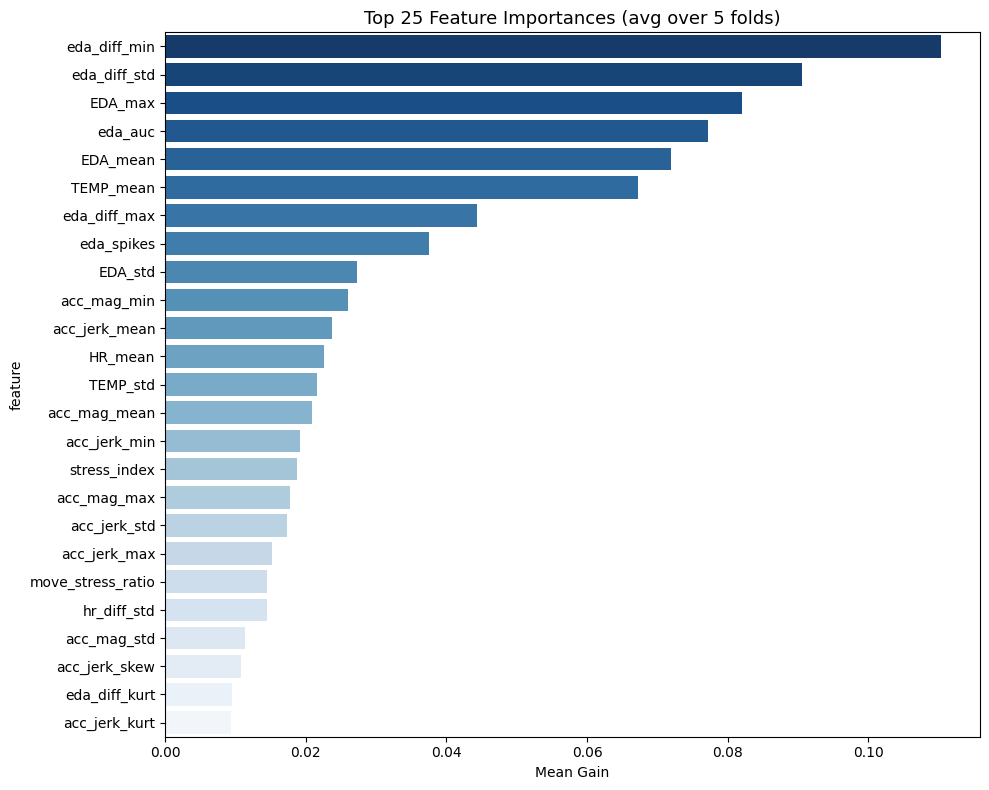

Saved: feature_importance.png


In [27]:
avg_importances = feature_importances / 5  # average over 5 folds
imp_df = pd.DataFrame({'feature': X.columns, 'importance': avg_importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df, x='importance', y='feature', palette='Blues_r')
plt.title('Top 25 Feature Importances (avg over 5 folds)', fontsize=13)
plt.xlabel('Mean Gain')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Saved: feature_importance.png')

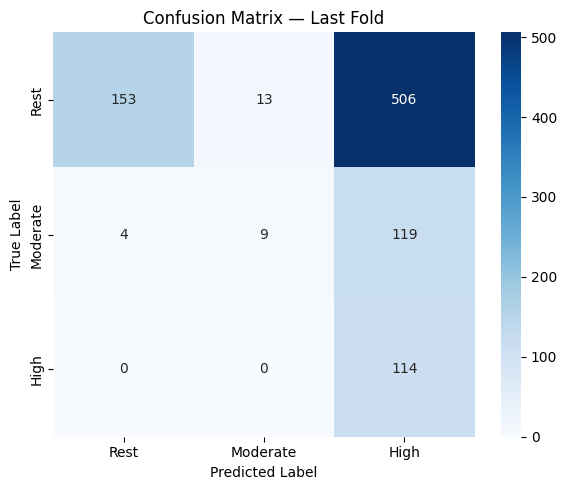

Saved: confusion_matrix.png


In [29]:
train_idx_last, val_idx_last = list(sgkf.split(X, y, groups=groups))[-1]
X_tr_last, X_val_last = X.iloc[train_idx_last], X.iloc[val_idx_last]
y_tr_last, y_val_last = y[train_idx_last],      y[val_idx_last]
sw_last = compute_sample_weight('balanced', y_tr_last)

model_last = xgb.XGBClassifier(**best_params)
model_last.fit(X_tr_last, y_tr_last,
               sample_weight=sw_last,
               eval_set=[(X_val_last, y_val_last)],
               verbose=False)

y_pred_last = model_last.predict(X_val_last)
cm = confusion_matrix(y_val_last, y_pred_last)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rest', 'Moderate', 'High'],
            yticklabels=['Rest', 'Moderate', 'High'])
plt.title('Confusion Matrix — Last Fold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

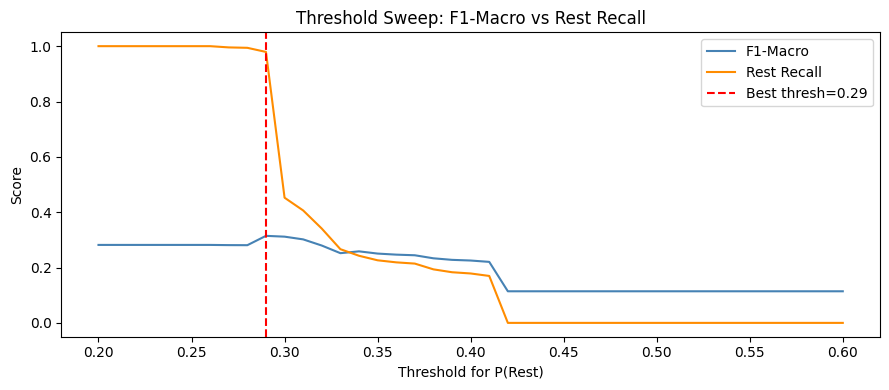


Best threshold (Rest recall ≥ 0.50): 0.29

Classification report with tuned threshold:
              precision    recall  f1-score   support

     Rest(0)      0.736     0.979     0.840       672
 Moderate(1)      0.500     0.030     0.057       132
     High(2)      0.188     0.026     0.046       114

    accuracy                          0.724       918
   macro avg      0.475     0.345     0.315       918
weighted avg      0.634     0.724     0.629       918



In [30]:
from sklearn.metrics import recall_score

y_prob_last = model_last.predict_proba(X_val_last)  # shape (n, 3)

# For each threshold on P(rest), if P(rest) >= thresh → predict Rest
# otherwise argmax of remaining classes
best_thresh = 0.33
best_f1     = 0.0
results_thresh = []

for thresh in np.linspace(0.20, 0.60, 41):
    y_custom = np.where(
        y_prob_last[:, 0] >= thresh,
        0,
        np.argmax(y_prob_last[:, 1:], axis=1) + 1
    )
    f1_m = f1_score(y_val_last, y_custom, average='macro', zero_division=0)
    rec0 = recall_score(y_val_last, y_custom, labels=[0], average='macro', zero_division=0)
    results_thresh.append({'thresh': thresh, 'f1_macro': f1_m, 'rest_recall': rec0})
    if f1_m > best_f1 and rec0 >= 0.50:
        best_f1     = f1_m
        best_thresh = thresh

thresh_df = pd.DataFrame(results_thresh)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(thresh_df['thresh'], thresh_df['f1_macro'],   label='F1-Macro',    color='steelblue')
ax1.plot(thresh_df['thresh'], thresh_df['rest_recall'], label='Rest Recall', color='darkorange')
ax1.axvline(best_thresh, color='red', linestyle='--', label=f'Best thresh={best_thresh:.2f}')
ax1.set_xlabel('Threshold for P(Rest)')
ax1.set_ylabel('Score')
ax1.legend()
ax1.set_title('Threshold Sweep: F1-Macro vs Rest Recall')
plt.tight_layout()
plt.savefig('threshold_sweep.png', dpi=150)
plt.show()

print(f'\nBest threshold (Rest recall ≥ 0.50): {best_thresh:.2f}')

# Apply best threshold
y_tuned = np.where(
    y_prob_last[:, 0] >= best_thresh,
    0,
    np.argmax(y_prob_last[:, 1:], axis=1) + 1
)
print('\nClassification report with tuned threshold:')
print(classification_report(y_val_last, y_tuned,
                              target_names=['Rest(0)', 'Moderate(1)', 'High(2)'],
                              digits=3))

In [31]:
import json

model_last.save_model('nurse_stress_xgb.json')
print('Model saved to nurse_stress_xgb.json')

feature_list = list(X.columns)
with open('feature_list.json', 'w') as f:
    json.dump(feature_list, f, indent=2)
print(f'Feature list ({len(feature_list)} features) saved to feature_list.json')

# Save threshold
with open('best_threshold.json', 'w') as f:
    json.dump({'rest_threshold': float(best_thresh)}, f)
print(f'Best Rest threshold ({best_thresh:.2f}) saved to best_threshold.json')

Model saved to nurse_stress_xgb.json
Feature list (49 features) saved to feature_list.json
Best Rest threshold (0.29) saved to best_threshold.json


In [32]:
import json

# ── 1. Save model artifacts ──────────────────────────────────────────────────
model_last.save_model('nurse_stress_xgb.json')
feature_list = list(X.columns)
with open('feature_list.json', 'w') as f:
    json.dump(feature_list, f, indent=2)
with open('best_threshold.json', 'w') as f:
    json.dump({'rest_threshold': float(best_thresh)}, f)
print('Model + feature list + threshold saved.')

# ── 2. Prepare TEST data (same pipeline as train) ────────────────────────────
TEST_DATA_RAW = pd.read_csv(DATA_DIR / 'test-sensor.csv')
TEST_LABEL    = pd.read_csv(DATA_DIR / 'test-label.csv')

TEST_DATA_RAW = clean_sensor(TEST_DATA_RAW)
TEST_LABEL['id']        = pd.to_numeric(TEST_LABEL['id'], errors='raise').astype(int)
TEST_LABEL['pid']       = TEST_LABEL['pid'].astype(str)
TEST_LABEL['timestamp'] = pd.to_numeric(TEST_LABEL['timestamp'], errors='coerce').astype(float)

# ── 3. For each test label row: extract a window centred on its timestamp ────
HALF_WIN = WINDOW_SIZE // 2   # 160 samples each side

def extract_window_for_row(sensor_df, pid, ts_ms):
    """Return a WINDOW_SIZE slice of sensor_df centred on ts_ms for given pid."""
    grp = sensor_df[sensor_df['pid'] == pid].reset_index(drop=True)
    if grp.empty:
        return None
    # find closest sample index
    idx_closest = (grp['timestamp'] - ts_ms).abs().idxmin()
    start = max(0, idx_closest - HALF_WIN)
    end   = start + WINDOW_SIZE
    if end > len(grp):
        end   = len(grp)
        start = max(0, end - WINDOW_SIZE)
    window = grp.iloc[start:end]
    if len(window) < WINDOW_SIZE:
        return None
    return window

# Build feature rows aligned to each test label id
test_feats = []
test_ids   = []

for _, row in TEST_LABEL.iterrows():
    pid = str(row['pid'])
    ts  = row['timestamp']
    rid = int(row['id'])

    window_raw = extract_window_for_row(TEST_DATA_RAW, pid, ts)
    if window_raw is None:
        # fallback: fill with zeros
        test_feats.append({col: 0.0 for col in feature_list})
        test_ids.append(rid)
        continue

    # rename to pipeline column names
    w = window_raw.rename(columns={
        'accel_x': 'X', 'accel_y': 'Y', 'accel_z': 'Z',
        'eda': 'EDA', 'heart_rate': 'HR', 'temperature': 'TEMP'
    })

    # per-pid z-score normalisation using test sensor stats
    grp_all = TEST_DATA_RAW[TEST_DATA_RAW['pid'] == pid]
    for src, dst in [('accel_x','X'),('accel_y','Y'),('accel_z','Z'),
                     ('eda','EDA'),('heart_rate','HR'),('temperature','TEMP')]:
        mu  = grp_all[src].mean()
        sig = grp_all[src].std()
        sig = sig if sig > 0 else 1.0
        w[dst] = (w[dst] - mu) / sig

    feats = extract_features(w)
    test_feats.append(feats)
    test_ids.append(rid)

X_test = pd.DataFrame(test_feats, columns=feature_list).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], 0)

# ── 4. Predict with tuned threshold ─────────────────────────────────────────
y_prob_test = model_last.predict_proba(X_test)
y_pred_test = np.where(
    y_prob_test[:, 0] >= best_thresh,
    0,
    np.argmax(y_prob_test[:, 1:], axis=1) + 1
)

# ── 5. Save submission ───────────────────────────────────────────────────────
submission = pd.DataFrame({'id': test_ids, 'stress': y_pred_test})
submission.to_csv('subn1.csv', index=False)
print(f'Saved subn1.csv  —  {len(submission)} rows')
print(submission['stress'].value_counts().sort_index())

Model + feature list + threshold saved.
Saved subn1.csv  —  1028 rows
stress
0    983
1     18
2     27
Name: count, dtype: int64
